In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
  
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Yeo-Johnson Transformation for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.785036,1,0,1,0,0,1,0.0,0,-1.533345,0.0,0.750782,0.080033,0.343545
1,-0.746998,0,0,0,0,1,0,0.0,1,0.397233,0.0,-1.213660,-1.722060,-1.657833
2,-0.175256,0,1,0,0,0,1,0.0,1,0.830437,1.0,-0.474112,0.735716,0.318631
3,1.371631,0,0,0,0,1,0,0.0,1,0.727938,0.0,-1.992620,-1.291020,-1.835650
4,0.987008,0,0,0,0,1,0,0.0,1,1.144253,0.0,-1.106304,-0.816679,-1.003396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.007949,0,0,1,0,0,1,1.0,0,-1.533345,0.0,-0.158214,-0.822461,-0.611074
135,1.111443,0,0,1,0,0,1,1.0,0,-1.533345,1.0,-0.632361,1.008070,0.474941
136,-0.370651,0,0,1,0,0,1,1.0,1,0.786825,0.0,0.658564,-0.170908,0.133612
137,0.696583,0,0,1,0,0,1,1.0,1,1.554125,1.0,-0.551725,0.574668,0.197985


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

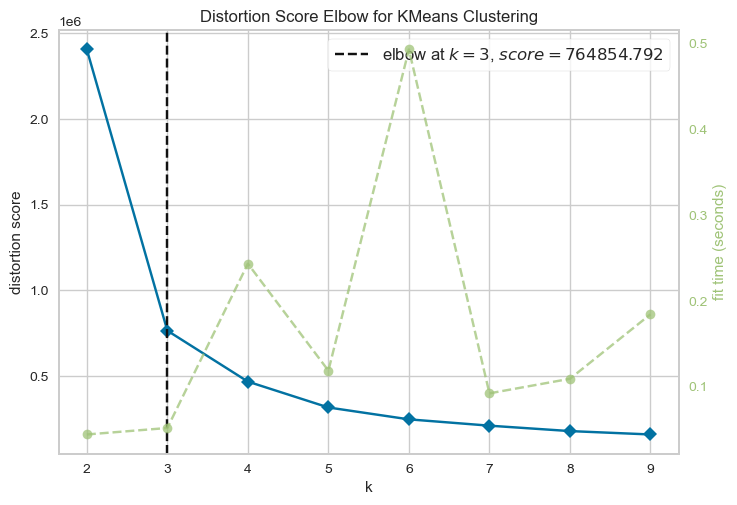

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 3 
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=3)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: uicc8_III-IV, Coefficient: 0.7453487384398209


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: TLG, Coefficient: -2.480289577727188


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 2: Most important feature: hpv_related, Coefficient: -1.229060383408114


In [22]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

In [24]:
# Selecct the columns from X_MAASTRO
MAASTRO_new = X_MAASTRO.loc[:, selected_features]

# Yeo-Johnson Transformation

In [44]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

X_new_std = X_new_std[X_new.columns]
MAASTRO_new  = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [45]:
X_new

,uicc8_III-IV,TLG,hpv_related
0,0.0,86.228420,0.0
1,0.0,7.040100,0.0
2,1.0,83.569669,0.0
3,0.0,5.567091,0.0
4,0.0,16.150550,0.0
...,...,...,...
134,0.0,26.280140,1.0
135,1.0,101.754834,1.0
136,0.0,66.273201,1.0
137,1.0,71.832443,1.0


In [46]:
X_new_std

,uicc8_III-IV,TLG,hpv_related
0,0.0,0.343545,0.0
1,0.0,-1.657833,0.0
2,1.0,0.318631,0.0
3,0.0,-1.835650,0.0
4,0.0,-1.003396,0.0
...,...,...,...
134,0.0,-0.611074,1.0
135,1.0,0.474941,1.0
136,0.0,0.133612,1.0
137,1.0,0.197985,1.0


In [47]:
MAASTRO_new

,uicc8_III-IV,TLG,hpv_related
0,0,263.611623,1
1,1,36.980700,0
2,1,74.636342,0
3,1,46.791979,0
4,0,107.637514,1
...,...,...,...
94,1,144.490782,0
95,1,69.214868,0
96,1,102.594274,1
97,0,103.229492,1


In [48]:
MAASTRO_new_std

,uicc8_III-IV,TLG,hpv_related
0,0,1.218887,1
1,1,-0.335276,0
2,1,0.228548,0
3,1,-0.145668,0
4,0,0.519421,1
...,...,...,...
94,1,0.751363,0
95,1,0.168333,0
96,1,0.481447,1
97,0,0.486335,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [49]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:34:54,551] A new study created in memory with name: no-name-b664c739-c7ff-4bfb-8097-1b6c3aad4b47


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772


[I 2024-04-13 17:34:54,961] A new study created in memory with name: no-name-d71129de-093e-4931-8f23-ee0d372d8749


Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:34:54,956] Trial 0 finished with value: 0.6591392942754536 and parameters: {}. Best is trial 0 with value: 0.6591392942754536.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6591392942754536], datetime_start=datetime.datetime(2024, 4, 13, 17, 34, 54, 603394), datetime_complete=datetime.datetime(2024, 4, 13, 17, 34, 54, 956030), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6591392942754536


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23475478737128683
Fold 2 IBS: 0.22083005204274042
Fold 3 IBS: 0.184526579580071
Fold 4 IBS: 0.25186541659201134
Fold 5 IBS: 0.21044474724669837
[I 2024-04-13 17:34:56,083] Trial 0 finished with value: 0.2204843165665616 and parameters: {}. Best is trial 0 with value: 0.2204843165665616.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2204843165665616], datetime_start=datetime.datetime(2024, 4, 13, 17, 34, 54, 995429), datetime_complete=datetime.datetime(2024, 4, 13, 17, 34, 56, 82722), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2204843165665616


In [50]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.659
train_ibs:  0.22


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.659
IBS score: 0.226


In [54]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [55]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [56]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:34:56,433] A new study created in memory with name: no-name-db6a19ce-8ca9-4eaa-b648-071007349335


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5956175298804781
Fold 2 C-index: 0.6065891472868217


[I 2024-04-13 17:34:56,998] A new study created in memory with name: no-name-90a4f88a-235e-4937-9587-4fc4863413ca


Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:34:56,989] Trial 0 finished with value: 0.6073167670571498 and parameters: {}. Best is trial 0 with value: 0.6073167670571498.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6073167670571498], datetime_start=datetime.datetime(2024, 4, 13, 17, 34, 56, 572255), datetime_complete=datetime.datetime(2024, 4, 13, 17, 34, 56, 988996), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6073167670571498


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709745894363
Fold 2 IBS: 0.23203988107242277
Fold 3 IBS: 0.22898186333477166
Fold 4 IBS: 0.24197477528164696
Fold 5 IBS: 0.22939558993058365
[I 2024-04-13 17:34:57,624] Trial 0 finished with value: 0.23592784141567374 and parameters: {}. Best is trial 0 with value: 0.23592784141567374.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784141567374], datetime_start=datetime.datetime(2024, 4, 13, 17, 34, 57, 94434), datetime_complete=datetime.datetime(2024, 4, 13, 17, 34, 57, 623913), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784141567374


In [57]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [58]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.607
train_ibs:  0.236


#### Test

In [59]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [60]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.645


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [61]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [62]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:34:57,998] A new study created in memory with name: no-name-9afd4bdf-6fa5-40fe-9228-3a1c4f37bc1c


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772


[I 2024-04-13 17:34:58,945] A new study created in memory with name: no-name-463ea231-f6a7-4b62-b40d-b8dc2201b5d8


Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:34:58,939] Trial 0 finished with value: 0.6591392942754536 and parameters: {}. Best is trial 0 with value: 0.6591392942754536.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6591392942754536], datetime_start=datetime.datetime(2024, 4, 13, 17, 34, 58, 153625), datetime_complete=datetime.datetime(2024, 4, 13, 17, 34, 58, 938613), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6591392942754536


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23437423227732362
Fold 2 IBS: 0.22024536470981543
Fold 3 IBS: 0.18550393009252453
Fold 4 IBS: 0.25130344644734076
Fold 5 IBS: 0.2104321222584314
[I 2024-04-13 17:34:59,853] Trial 0 finished with value: 0.22037181915708715 and parameters: {}. Best is trial 0 with value: 0.22037181915708715.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22037181915708715], datetime_start=datetime.datetime(2024, 4, 13, 17, 34, 58, 984218), datetime_complete=datetime.datetime(2024, 4, 13, 17, 34, 59, 852691), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22037181915708715


In [63]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [64]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.659
train_ibs:  0.22


#### Test

In [65]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [66]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.659


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.225


In [67]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [68]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:35:00,348] A new study created in memory with name: no-name-3c627cbd-7713-4db2-85a3-ce2eea8c217d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:35:01,181] Trial 0 finished with value: 0.6591392942754536 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6591392942754536.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:35:01,974] Trial 1 finished with value: 0.659997663374166 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.659997663374166.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:35:02,874] Trial 2 finished with value: 0.659997663374166 and parameters: {'l1_ratio': 0.22692876841884668}. Be

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:35:19,957] Trial 24 finished with value: 0.6188780128604534 and parameters: {'l1_ratio': 0.16645977610301255}. Best is trial 1 with value: 0.659997663374166.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:35:20,902] Trial 25 finished with value: 0.659997663374166 and parameters: {'l1_ratio': 0.44908780975162055}. Best is trial 1 with value: 0.659997663374166.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:35:21,716] Trial 26 finished with value: 0.659997663374166 and parameters: {'l1_ratio': 0.2080204609486906}. 

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:35:38,584] Trial 48 finished with value: 0.6591392942754536 and parameters: {'l1_ratio': 0.5683872043393509}. Best is trial 1 with value: 0.659997663374166.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:35:39,353] Trial 49 finished with value: 0.6591392942754536 and parameters: {'l1_ratio': 0.46569877065454696}. Best is trial 1 with value: 0.659997663374166.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:35:40,157] Trial 50 finished with value: 0.659997663374166 and parameters: {'l1_ratio': 0.374354691474329}. B

...

Fold 1 IBS: 0.23438831604516744
Fold 2 IBS: 0.2201961421580724
Fold 3 IBS: 0.18531147523733119
Fold 4 IBS: 0.25145161714421677
Fold 5 IBS: 0.21037714249576142
[I 2024-04-13 17:36:29,862] Trial 0 finished with value: 0.22034493861610988 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22034493861610988.
Fold 1 IBS: 0.23437555433082088
Fold 2 IBS: 0.22010084507680666
Fold 3 IBS: 0.1850524706008501
Fold 4 IBS: 0.25167660673341363
Fold 5 IBS: 0.21029482761524168
[I 2024-04-13 17:36:31,114] Trial 1 finished with value: 0.2203000608714266 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.2203000608714266.
Fold 1 IBS: 0.23440313285791495
Fold 2 IBS: 0.22006823484261
Fold 3 IBS: 0.1849627880789934
Fold 4 IBS: 0.2517182618757969
Fold 5 IBS: 0.21027915009623177
[I 2024-04-13 17:36:32,183] Trial 2 finished with value: 0.22028631355030942 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.22028631355030942.

Fold 2 IBS: 0.22009546098949911
Fold 3 IBS: 0.18499822783007838
Fold 4 IBS: 0.25170197931918586
Fold 5 IBS: 0.21028561895668235
[I 2024-04-13 17:36:53,888] Trial 25 finished with value: 0.22029285230898613 and parameters: {'l1_ratio': 0.2358449311393074}. Best is trial 21 with value: 0.22028013931987456.
Fold 1 IBS: 0.23439977350462562
Fold 2 IBS: 0.22010904274049242
Fold 3 IBS: 0.18506374904177925
Fold 4 IBS: 0.2516283991441168
Fold 5 IBS: 0.2103066313222303
[I 2024-04-13 17:36:54,863] Trial 26 finished with value: 0.2203015191506489 and parameters: {'l1_ratio': 0.34875619959435994}. Best is trial 21 with value: 0.22028013931987456.
Fold 1 IBS: 0.23438634545551926
Fold 2 IBS: 0.22012567051066498
Fold 3 IBS: 0.18517584100158477
Fold 4 IBS: 0.2515368708626833
Fold 5 IBS: 0.21033022777543275
[I 2024-04-13 17:36:56,173] Trial 27 finished with value: 0.220310991121177 and parameters: {'l1_ratio': 0.4721718919654776}. Best is trial 21 with value: 0.22028013931987456.
Fold 1 IBS: 0.245134517

Fold 2 IBS: 0.22008771692625104
Fold 3 IBS: 0.1850375082694519
Fold 4 IBS: 0.25165475812780014
Fold 5 IBS: 0.21029622135208928
[I 2024-04-13 17:37:15,037] Trial 50 finished with value: 0.22029461428169572 and parameters: {'l1_ratio': 0.30818996965719153}. Best is trial 21 with value: 0.22028013931987456.
Fold 1 IBS: 0.23439678084406085
Fold 2 IBS: 0.2200522611265254
Fold 3 IBS: 0.18496723830242295
Fold 4 IBS: 0.25171927465933086
Fold 5 IBS: 0.21027540458660746
[I 2024-04-13 17:37:15,804] Trial 51 finished with value: 0.22028219190378953 and parameters: {'l1_ratio': 0.2219877397804939}. Best is trial 21 with value: 0.22028013931987456.
Fold 1 IBS: 0.2343890435783125
Fold 2 IBS: 0.22007494177672823
Fold 3 IBS: 0.22310630780157864
Fold 4 IBS: 0.24592351217619698
Fold 5 IBS: 0.21026917312028748
[I 2024-04-13 17:37:16,596] Trial 52 finished with value: 0.22675259569062076 and parameters: {'l1_ratio': 0.15795204495445236}. Best is trial 21 with value: 0.22028013931987456.
Fold 1 IBS: 0.23440

Fold 1 IBS: 0.23437537620026916
Fold 2 IBS: 0.2200778250103286
Fold 3 IBS: 0.1850036291288112
Fold 4 IBS: 0.251717652100922
Fold 5 IBS: 0.21028141760692295
[I 2024-04-13 17:37:35,164] Trial 75 finished with value: 0.22029118000945078 and parameters: {'l1_ratio': 0.22999588610755692}. Best is trial 57 with value: 0.21924817006242786.
Fold 1 IBS: 0.23440678697328318
Fold 2 IBS: 0.22005056841167336
Fold 3 IBS: 0.22283305263809208
Fold 4 IBS: 0.24607110731166842
Fold 5 IBS: 0.21026603430819346
[I 2024-04-13 17:37:35,854] Trial 76 finished with value: 0.2267255099285821 and parameters: {'l1_ratio': 0.16759309980380477}. Best is trial 57 with value: 0.21924817006242786.
Fold 1 IBS: 0.23438178600677043
Fold 2 IBS: 0.2201034950054019
Fold 3 IBS: 0.18502240940385567
Fold 4 IBS: 0.2516807711021009
Fold 5 IBS: 0.21029130625751216
[I 2024-04-13 17:37:36,634] Trial 77 finished with value: 0.22029595355512824 and parameters: {'l1_ratio': 0.26183067731747267}. Best is trial 57 with value: 0.219248170

Fold 5 IBS: 0.21026199955997138
[I 2024-04-13 17:37:53,037] Trial 99 finished with value: 0.2267300448478471 and parameters: {'l1_ratio': 0.16363517815348244}. Best is trial 93 with value: 0.21923905668904978.


* Best trial for IBS: 
 FrozenTrial(number=93, state=TrialState.COMPLETE, values=[0.21923905668904978], datetime_start=datetime.datetime(2024, 4, 13, 17, 37, 47, 997118), datetime_complete=datetime.datetime(2024, 4, 13, 17, 37, 48, 777234), params={'l1_ratio': 0.20106835209432652}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=93, value=None)


* Best Score for IBS: 
 0.21923905668904978


In [69]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [70]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.66
train_ibs:  0.219


#### Test

In [71]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [72]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.28621072101688444)

test_cindex : 0.659


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.20106835209432652)

test_ibs:  0.225


In [73]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [74]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:37:53,648] A new study created in memory with name: no-name-872fd641-124d-4153-8ef3-7b16074e9fc4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6075697211155379
Fold 2 C-index: 0.5833333333333334
Fold 3 C-index: 0.7170212765957447
Fold 4 C-index: 0.6825095057034221
Fold 5 C-index: 0.555793991416309
[I 2024-04-13 17:38:01,735] Trial 0 finished with value: 0.6292455656328694 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6292455656328694.
Fold 1 C-index: 0.6195219123505976
Fold 2 C-index: 0.6356589147286822
Fold 3 C-index: 0.6893617021276596
Fold 4 C-index: 0.6901140684410646
Fold 5 C-index: 0.6137339055793991
[I 2024-04-13 17:38:10,268] Trial 1 finished with value: 0.6496781006454807 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.6051502145922747
[I 2024-04-13 17:39:26,203] Trial 15 finished with value: 0.6755298325042801 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 1, 'n_estimators': 383, 'oob_score': True, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.19147439464820804, 'warm_start': True}. Best is trial 14 with value: 0.6761817783993471.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.823404255319149
Fold 4 C-index: 0.6996197718631179
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:39:32,179] Trial 16 finished with value: 0.6813837329111704 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.8353789630965257, 'max_features': None, 'min_weight_fraction_leaf': 0.18739880110892437, 'warm_start': True}. Best is trial 16 with value: 0.6813837329111704

Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.6996124031007752
Fold 3 C-index: 0.823404255319149
Fold 4 C-index: 0.7243346007604563
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 17:40:54,185] Trial 30 finished with value: 0.7013331863640586 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 3, 'n_estimators': 370, 'oob_score': True, 'max_samples': 0.6943675482902832, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.12851831046148365, 'warm_start': True}. Best is trial 29 with value: 0.7076495695091999.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.7073643410852714
Fold 3 C-index: 0.823404255319149
Fold 4 C-index: 0.7281368821292775
Fold 5 C-index: 0.6523605150214592
[I 2024-04-13 17:40:59,670] Trial 31 finished with value: 0.7053607684321468 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 3, 'n_estimators': 371, 'oob_score': True, 'max_samples': 0.6873422761646968, '

...

Fold 5 IBS: 0.21210543485578207
[I 2024-04-13 17:47:06,957] Trial 31 finished with value: 0.21620936538191407 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 12, 'max_depth': 1, 'n_estimators': 148, 'oob_score': False, 'max_samples': 0.7751882647778675, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.10840109659544778}. Best is trial 13 with value: 0.2156854633223463.
Fold 1 IBS: 0.23247862021828997
Fold 2 IBS: 0.21477302166923723
Fold 3 IBS: 0.19502988852451375
Fold 4 IBS: 0.23465443274632494
Fold 5 IBS: 0.21320908981245199
[I 2024-04-13 17:47:09,708] Trial 32 finished with value: 0.21802901059416357 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 89, 'oob_score': False, 'max_samples': 0.8172282883080632, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.08899019798638996}. Best is trial 13 with value: 0.2156854633223463.
Fold 1 IBS: 0.23262475438189972
Fold 2 IBS: 0.219

Fold 1 IBS: 0.23203775832092768
Fold 2 IBS: 0.21701050937326852
Fold 3 IBS: 0.19448179419266082
Fold 4 IBS: 0.23646400372008977
Fold 5 IBS: 0.21358513034691337
[I 2024-04-13 17:48:33,017] Trial 47 finished with value: 0.21871583919077203 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 17, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 134, 'oob_score': True, 'max_samples': 0.8110946569280925, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1465084148058519}. Best is trial 13 with value: 0.2156854633223463.
Fold 1 IBS: 0.24633733887993117
Fold 2 IBS: 0.23209283242828452
Fold 3 IBS: 0.22946923147181247
Fold 4 IBS: 0.24147474681291295
Fold 5 IBS: 0.23035529240553526
[I 2024-04-13 17:48:36,224] Trial 48 finished with value: 0.23594588839969527 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 20, 'min_samples_leaf': 10, 'max_depth': 4, 'n_estimators': 104, 'oob_score': False, 'max_samples': 0.6876926511862407, 'max_features': 'auto', 'min_weight_fraction

Fold 1 IBS: 0.23344087535897642
Fold 2 IBS: 0.2198514440712789
Fold 3 IBS: 0.19446313991870448
Fold 4 IBS: 0.23650123650799668
Fold 5 IBS: 0.21392164734900135
[I 2024-04-13 17:49:43,060] Trial 63 finished with value: 0.2196356686411916 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 12, 'max_depth': 11, 'n_estimators': 61, 'oob_score': False, 'max_samples': 0.781887856767589, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.15473314207245076}. Best is trial 13 with value: 0.2156854633223463.
Fold 1 IBS: 0.23498501451935047
Fold 2 IBS: 0.21389681532411783
Fold 3 IBS: 0.19375364148034857
Fold 4 IBS: 0.23617688573644877
Fold 5 IBS: 0.21241309583761026
[I 2024-04-13 17:49:47,382] Trial 64 finished with value: 0.2182450905795752 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 10, 'max_depth': 2, 'n_estimators': 136, 'oob_score': False, 'max_samples': 0.8904838185588615, 'max_features': 'auto', 'min_weight_fraction_le

Fold 5 IBS: 0.2123146228615816
[I 2024-04-13 17:51:16,354] Trial 78 finished with value: 0.21967072860725073 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 7, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 242, 'oob_score': False, 'max_samples': 0.8347191036807436, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.04534811658520228}. Best is trial 77 with value: 0.21421860912763052.
Fold 1 IBS: 0.2340684259255293
Fold 2 IBS: 0.20963655251423713
Fold 3 IBS: 0.1909782042835311
Fold 4 IBS: 0.22631291693870995
Fold 5 IBS: 0.21106258565210903
[I 2024-04-13 17:51:23,155] Trial 79 finished with value: 0.2144117370628233 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 5, 'min_samples_leaf': 7, 'max_depth': 1, 'n_estimators': 224, 'oob_score': False, 'max_samples': 0.8957094147665324, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.09324092610365284}. Best is trial 77 with value: 0.21421860912763052.
Fold 1 IBS: 0.2417816296464201
Fold 2 IBS: 0.2239174

Fold 1 IBS: 0.24483837956738988
Fold 2 IBS: 0.23559399752420804
Fold 3 IBS: 0.19214204784399075
Fold 4 IBS: 0.2252520012335488
Fold 5 IBS: 0.2125878692207323
[I 2024-04-13 17:54:18,899] Trial 94 finished with value: 0.22208285907797398 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 334, 'oob_score': True, 'max_samples': 0.988703130238359, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.013413769235196223}. Best is trial 81 with value: 0.21381080066947108.
Fold 1 IBS: 0.24010838814237961
Fold 2 IBS: 0.22129511191559176
Fold 3 IBS: 0.19039199936459633
Fold 4 IBS: 0.22624408372188157
Fold 5 IBS: 0.21209655442152767
[I 2024-04-13 17:54:36,196] Trial 95 finished with value: 0.21802722751319537 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 382, 'oob_score': True, 'max_samples': 0.9073233001577026, 'max_features': 'log2', 'min_weight_fraction_le

In [75]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [76]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.799
train_ibs:  0.214


#### Test

In [77]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [78]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=18, max_leaf_nodes=19,
                     max_samples=0.6588200444221712, min_samples_leaf=1,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.002214014196689788,
                     n_estimators=368, random_state=123, warm_start=True)

test_cindex:  0.612


RandomSurvivalForest(max_depth=1, max_features='log2', max_leaf_nodes=9,
                     max_samples=0.9440737943086028, min_samples_leaf=7,
                     min_samples_split=11,
                     min_weight_fraction_leaf=0.05977602121521218,
                     n_estimators=220, random_state=123)

test_ibs:  0.213


In [79]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [80]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:55:34,452] A new study created in memory with name: no-name-6594e45e-7edc-4088-a886-b166f67c31bb


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6075697211155379
Fold 2 C-index: 0.6841085271317829
Fold 3 C-index: 0.8106382978723404
Fold 4 C-index: 0.7243346007604563
Fold 5 C-index: 0.6180257510729614
[I 2024-04-13 17:55:38,741] Trial 0 finished with value: 0.6889353795906158 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6889353795906158.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:55:47,069] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.5450643776824035
[I 2024-04-13 17:57:25,074] Trial 15 finished with value: 0.6631972139094079 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.699467787831579.
Fold 1 C-index: 0.5956175298804781
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.6863117870722434
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:57:29,501] Trial 16 finished with value: 0.6667754848119712 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_l

Fold 1 C-index: 0.6075697211155379
Fold 2 C-index: 0.6841085271317829
Fold 3 C-index: 0.823404255319149
Fold 4 C-index: 0.7395437262357415
Fold 5 C-index: 0.6630901287553648
[I 2024-04-13 17:58:33,628] Trial 30 finished with value: 0.7035432717115151 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 398, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6204655821432031, 'min_weight_fraction_leaf': 0.08941926090357169}. Best is trial 30 with value: 0.7035432717115151.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.8191489361702128
Fold 4 C-index: 0.7110266159695817
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:58:37,435] Trial 31 finished with value: 0.6812636503057766 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 398, 'oob_score': False, 'warm_start': True, 'max_features':

...

Fold 1 IBS: 0.23318274686592516
Fold 2 IBS: 0.2187372539062478
Fold 3 IBS: 0.1947858355847726
Fold 4 IBS: 0.22521167126983738
Fold 5 IBS: 0.2060394803166081
[I 2024-04-13 18:08:36,955] Trial 30 finished with value: 0.2155913975886782 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 326, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6312098987792154, 'min_weight_fraction_leaf': 0.001306576414643712}. Best is trial 22 with value: 0.21541822992814272.
Fold 1 IBS: 0.23330434095813854
Fold 2 IBS: 0.21883118916670644
Fold 3 IBS: 0.19499897888606424
Fold 4 IBS: 0.22524399827750333
Fold 5 IBS: 0.20617675720663936
[I 2024-04-13 18:08:49,656] Trial 31 finished with value: 0.21571105289901035 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 324, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples':

Fold 1 IBS: 0.23296366192283832
Fold 2 IBS: 0.21888882272606747
Fold 3 IBS: 0.1991515797959291
Fold 4 IBS: 0.22857514356217212
Fold 5 IBS: 0.21007140310706574
[I 2024-04-13 18:11:41,136] Trial 45 finished with value: 0.21793012222281458 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 7, 'min_samples_leaf': 12, 'max_depth': 2, 'n_estimators': 425, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9526739138215993, 'min_weight_fraction_leaf': 0.0029036449449645514}. Best is trial 42 with value: 0.21536797593376034.
Fold 1 IBS: 0.23342812522317047
Fold 2 IBS: 0.21959943266705415
Fold 3 IBS: 0.20079081497031573
Fold 4 IBS: 0.22713290673074113
Fold 5 IBS: 0.21121180977160375
[I 2024-04-13 18:11:51,353] Trial 46 finished with value: 0.21843261787257706 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 284, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_sampl

Fold 1 IBS: 0.2331449034994304
Fold 2 IBS: 0.21829802059999417
Fold 3 IBS: 0.19946444047386971
Fold 4 IBS: 0.22875315820479133
Fold 5 IBS: 0.2116987450745594
[I 2024-04-13 18:13:25,499] Trial 60 finished with value: 0.21827185357052897 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'n_estimators': 279, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9208992051748564, 'min_weight_fraction_leaf': 0.024035810582247324}. Best is trial 42 with value: 0.21536797593376034.
Fold 1 IBS: 0.23648026983583387
Fold 2 IBS: 0.21922689207452992
Fold 3 IBS: 0.19404941840302734
Fold 4 IBS: 0.22247691332090758
Fold 5 IBS: 0.20820019483120172
[I 2024-04-13 18:13:29,450] Trial 61 finished with value: 0.21608673769310008 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 3, 'n_estimators': 126, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 

Fold 1 IBS: 0.23116106120837424
Fold 2 IBS: 0.21890070509910386
Fold 3 IBS: 0.1975933427908626
Fold 4 IBS: 0.2238444155721083
Fold 5 IBS: 0.20646953475754515
[I 2024-04-13 18:15:21,956] Trial 75 finished with value: 0.2155938118855988 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 3, 'min_samples_leaf': 6, 'max_depth': 6, 'n_estimators': 342, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8997388009176541, 'min_weight_fraction_leaf': 0.028308822617180374}. Best is trial 71 with value: 0.21502565920457228.
Fold 1 IBS: 0.23279439669335927
Fold 2 IBS: 0.21912084890500966
Fold 3 IBS: 0.19616639899519173
Fold 4 IBS: 0.2228229245618969
Fold 5 IBS: 0.20519691961267414
[I 2024-04-13 18:15:30,761] Trial 76 finished with value: 0.21522029775362633 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 4, 'n_estimators': 307, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.895101

Fold 1 IBS: 0.2325273420830762
Fold 2 IBS: 0.21931956387638404
Fold 3 IBS: 0.19854416343790052
Fold 4 IBS: 0.22766545759649012
Fold 5 IBS: 0.20946264335762105
[I 2024-04-13 18:18:14,719] Trial 90 finished with value: 0.2175038340702944 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 450, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.7989889962474885, 'min_weight_fraction_leaf': 0.13185136970503816}. Best is trial 77 with value: 0.21497040436485002.
Fold 1 IBS: 0.23252932170792193
Fold 2 IBS: 0.21862936526467272
Fold 3 IBS: 0.19607082453588634
Fold 4 IBS: 0.22314139738140376
Fold 5 IBS: 0.20573951260699508
[I 2024-04-13 18:18:27,449] Trial 91 finished with value: 0.215222084299376 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 352, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.844137331252

In [81]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [82]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.754
train_ibs:  0.215


#### Test

In [83]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [84]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=7, max_features=None, max_leaf_nodes=18,
                   max_samples=0.5288376494614869, min_samples_leaf=1,
                   min_samples_split=13,
                   min_weight_fraction_leaf=0.0007048129343283678,
                   n_estimators=277, random_state=123, warm_start=True)

C-index score: 0.652


ExtraSurvivalTrees(max_depth=4, max_features=0.1, max_leaf_nodes=3,
                   max_samples=0.9275378424312315, min_samples_leaf=5,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.034309290889635705,
                   n_estimators=368, random_state=123, warm_start=True)

IBS: 0.219


In [85]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [86]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 18:20:40,668] A new study created in memory with name: no-name-67307de1-044f-4423-bbd3-91553fcb6370


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:21:40,947] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:22:11,536] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:39:09,973] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6547503295320661.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:41:14,454] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-13 19:01:22,245] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 22 with value: 0.6567802711331774.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 19:04:03,684] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.3509209656

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:25:17,231] Trial 55 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.804828042321909, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.23926982708415356, 'n_estimators': 162, 'criterion': 'squared_error', 'ccp_alpha': 0.40074886285106287, 'min_weight_fraction_leaf': 0.2779066644542128, 'max_features': 'sqrt', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 4, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 4}. Best is trial 45 with value: 0.23252197102047098.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:25:38,653] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6106355356441384, 'learning_rate': 0.017538150300

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:27:32,312] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9043457557527063, 'learning_rate': 0.08720647345857328, 'dropout_rate': 0.27193939046019544, 'n_estimators': 154, 'criterion': 'squared_error', 'ccp_alpha': 1.4111498627316026, 'min_weight_fraction_leaf': 0.23517339076530247, 'max_features': 'sqrt', 'min_impurity_decrease': 6.086951842225704e-07, 'validation_fraction': 0.9127218528145804, 'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 2}. Best is trial 63 with value: 0.23151152635175531.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:27:34,569] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8250695857763196, 'learning_rate': 0.09110863428

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:30:20,967] Trial 77 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7428517276581355, 'learning_rate': 0.07706989744762442, 'dropout_rate': 0.4476209058480567, 'n_estimators': 91, 'criterion': 'squared_error', 'ccp_alpha': 1.5888723787914292, 'min_weight_fraction_leaf': 0.16206442611838873, 'max_features': 0.1, 'min_impurity_decrease': 3.33671674086432e-07, 'validation_fraction': 0.9402673106586569, 'min_samples_split': 12, 'max_leaf_nodes': 13, 'min_samples_leaf': 17, 'max_depth': 9}. Best is trial 63 with value: 0.23151152635175531.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:30:32,247] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7715268987373948, 'learning_rate': 0.08985503754923349, 'dropout_rate': 0.51064243866

Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:31:54,379] Trial 88 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6413430388178152, 'learning_rate': 0.0973528090376961, 'dropout_rate': 0.26912242502602596, 'n_estimators': 174, 'criterion': 'squared_error', 'ccp_alpha': 0.5807061908097002, 'min_weight_fraction_leaf': 0.16723537370276506, 'max_features': 0.1, 'min_impurity_decrease': 1.190634063232502e-06, 'validation_fraction': 0.8005899065401637, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 4}. Best is trial 63 with value: 0.23151152635175531.
Fold 1 IBS: 0.2422827803203344
Fold 2 IBS: 0.22660287526849718
Fold 3 IBS: 0.22041683417748262
Fold 4 IBS: 0.23830802230842563
Fold 5 IBS: 0.2233538628205385
[I 2024-04-13 21:32:07,581] Trial 89 finished with value: 0.23019287497905566 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.08109800836387941, 'dropout_rate': 0.18122999434960108, 'n_estimators': 146, 'c

Fold 5 IBS: 0.22544455983201658
[I 2024-04-13 21:34:42,245] Trial 99 finished with value: 0.23147026973857768 and parameters: {'subsample': 0.40791967441342253, 'learning_rate': 0.07712333235501795, 'dropout_rate': 0.19859974199600133, 'n_estimators': 143, 'criterion': 'squared_error', 'ccp_alpha': 0.004426170739568851, 'min_weight_fraction_leaf': 0.16314282359709542, 'max_features': 'log2', 'min_impurity_decrease': 5.353566353972388e-07, 'validation_fraction': 0.1604355124738367, 'min_samples_split': 11, 'max_leaf_nodes': 15, 'min_samples_leaf': 14, 'max_depth': 4}. Best is trial 91 with value: 0.22929793797800135.


* Best trial for IBS: 
 FrozenTrial(number=91, state=TrialState.COMPLETE, values=[0.22929793797800135], datetime_start=datetime.datetime(2024, 4, 13, 21, 32, 40, 315612), datetime_complete=datetime.datetime(2024, 4, 13, 21, 32, 56, 798307), params={'subsample': 0.3646963250854607, 'learning_rate': 0.09255241886126767, 'dropout_rate': 0.12363276406693596, 'n_estimators': 1

In [87]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [88]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.678
train_ibs:  0.229


#### Test

In [89]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [90]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.01138981446692314,
                                 criterion='squared_error',
                                 dropout_rate=0.27756712303166453,
                                 learning_rate=0.05733879368918632, max_depth=8,
                                 max_features='sqrt', max_leaf_nodes=17,
                                 min_impurity_decrease=1.8112895315979708e-07,
                                 min_samples_leaf=11, min_samples_split=18,
                                 min_weight_fraction_leaf=0.275464327879998,
                                 n_estimators=3, random_state=123,
                                 subsample=0.4673519015749943,
                                 validation_fraction=0.829722204894956)

C-index score: 0.605


GradientBoostingSurvivalAnalysis(ccp_alpha=0.03832008885345805,
                                 criterion='squared_error',
                                 dropout_rate=0.12363276406693596,
                                 learning_rate=0.09255241886126767, max_depth=4,
                                 max_leaf_nodes=15,
                                 min_impurity_decrease=6.12703415921239e-07,
                                 min_samples_leaf=16, min_samples_split=13,
                                 min_weight_fraction_leaf=0.14198218649980035,
                                 n_estimators=143, random_state=123,
                                 subsample=0.3646963250854607,
                                 validation_fraction=0.965806971606102)

IBS: 0.221


In [91]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [92]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 21:34:45,787] A new study created in memory with name: no-name-ff691ff1-5746-4bcd-9ab8-55301ca77986


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.5703422053231939
Fold 5 C-index: 0.6244635193133047
[I 2024-04-13 21:34:47,290] Trial 0 finished with value: 0.6295122507464773 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6295122507464773.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.5703422053231939
Fold 5 C-index: 0.6244635193133047
[I 2024-04-13 21:34:59,873] Trial 1 finished with value: 0.6171616531369155 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6295122507464773.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7829787234042553
Fold 

Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.5893536121673004
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 21:36:50,220] Trial 19 finished with value: 0.6508253692639718 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7162662610965096, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.6508253692639718.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 21:36:51,328] Trial 20 finished with value: 0.6296588534217599 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.7605799565975376, 'n_estimators': 54, 'learning_rate': 0.03789546527738753}. Best is trial 12 with value: 0.6508253692639718.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7829787234042553
F

Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 21:37:41,219] Trial 38 finished with value: 0.6493044567164433 and parameters: {'subsample': 0.14784367538324486, 'dropout_rate': 0.38604460527645285, 'n_estimators': 33, 'learning_rate': 0.07288612365177065}. Best is trial 31 with value: 0.6525348021924715.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 21:37:44,355] Trial 39 finished with value: 0.648544000442679 and parameters: {'subsample': 0.23449348364633113, 'dropout_rate': 0.648848201803034, 'n_estimators': 200, 'learning_rate': 0.08379469554551444}. Best is trial 31 with value: 0.6525348021924715.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6065891472868217
Fold 3 C-index: 0.7446808510638298
F

...

Fold 2 IBS: 0.26222920493501467
Fold 3 IBS: 0.18619249998849396
Fold 4 IBS: 0.32113923348394874
Fold 5 IBS: 0.21061253502116778
[I 2024-04-13 21:42:12,024] Trial 19 finished with value: 0.25271758347245066 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.2379003838874303, 'n_estimators': 341, 'learning_rate': 0.0387255870496736}. Best is trial 17 with value: 0.22449559375258749.
Fold 1 IBS: 0.24235927274123295
Fold 2 IBS: 0.21955125468679798
Fold 3 IBS: 0.2051352926942895
Fold 4 IBS: 0.24518746934092925
Fold 5 IBS: 0.21143314654597437
[I 2024-04-13 21:42:14,292] Trial 20 finished with value: 0.22473328720184482 and parameters: {'subsample': 0.23495674638237363, 'dropout_rate': 0.3086154579845777, 'n_estimators': 152, 'learning_rate': 0.017331004877487094}. Best is trial 17 with value: 0.22449559375258749.
Fold 1 IBS: 0.24035649626405517
Fold 2 IBS: 0.2199691803584443
Fold 3 IBS: 0.20515352641443285
Fold 4 IBS: 0.24497967015445424
Fold 5 IBS: 0.21346589091945686
[I 2

Fold 2 IBS: 0.23908554973609836
Fold 3 IBS: 0.20026831015904042
Fold 4 IBS: 0.3051306806519925
Fold 5 IBS: 0.20457444131271071
[I 2024-04-13 21:42:46,695] Trial 38 finished with value: 0.2490518572014832 and parameters: {'subsample': 0.4537787849095529, 'dropout_rate': 0.13272164755980653, 'n_estimators': 203, 'learning_rate': 0.05073537862850462}. Best is trial 17 with value: 0.22449559375258749.
Fold 1 IBS: 0.23870178350671442
Fold 2 IBS: 0.21797956537855884
Fold 3 IBS: 0.19868479814159443
Fold 4 IBS: 0.24932627828974624
Fold 5 IBS: 0.2090899224289557
[I 2024-04-13 21:42:48,723] Trial 39 finished with value: 0.22275646954911393 and parameters: {'subsample': 0.12758528711699088, 'dropout_rate': 0.5066168130278461, 'n_estimators': 142, 'learning_rate': 0.02570451072541571}. Best is trial 39 with value: 0.22275646954911393.
Fold 1 IBS: 0.28081749607007833
Fold 2 IBS: 0.22552019669162268
Fold 3 IBS: 0.20047269152163458
Fold 4 IBS: 0.2682137460550317
Fold 5 IBS: 0.20120324465893502
[I 202

Fold 1 IBS: 0.24809512566458405
Fold 2 IBS: 0.2188060581725709
Fold 3 IBS: 0.18820482000791372
Fold 4 IBS: 0.2573860569550459
Fold 5 IBS: 0.20524725203942257
[I 2024-04-13 21:43:39,293] Trial 57 finished with value: 0.22354786256790743 and parameters: {'subsample': 0.14274328429776365, 'dropout_rate': 0.9866938906689144, 'n_estimators': 215, 'learning_rate': 0.024266682970685172}. Best is trial 39 with value: 0.22275646954911393.
Fold 1 IBS: 0.31088104958125273
Fold 2 IBS: 0.23892920389886535
Fold 3 IBS: 0.21388324207870266
Fold 4 IBS: 0.27850995535240175
Fold 5 IBS: 0.20536205536318625
[I 2024-04-13 21:43:42,991] Trial 58 finished with value: 0.24951310125488177 and parameters: {'subsample': 0.8496023174043259, 'dropout_rate': 0.979014529249458, 'n_estimators': 269, 'learning_rate': 0.037185619730233016}. Best is trial 39 with value: 0.22275646954911393.
Fold 1 IBS: 0.25713948200796566
Fold 2 IBS: 0.22306673851320122
Fold 3 IBS: 0.18543728212069913
Fold 4 IBS: 0.27747710012558746
Fold

Fold 1 IBS: 0.23878396407837893
Fold 2 IBS: 0.21796905128980365
Fold 3 IBS: 0.19971136846768262
Fold 4 IBS: 0.25132532979223593
Fold 5 IBS: 0.21008214226701274
[I 2024-04-13 21:44:34,769] Trial 76 finished with value: 0.2235743711790228 and parameters: {'subsample': 0.13270456176911696, 'dropout_rate': 0.45140420369583595, 'n_estimators': 203, 'learning_rate': 0.01569010424594094}. Best is trial 39 with value: 0.22275646954911393.
Fold 1 IBS: 0.2390081877297852
Fold 2 IBS: 0.2172886802483211
Fold 3 IBS: 0.19543228005000846
Fold 4 IBS: 0.24936647465739084
Fold 5 IBS: 0.20721769475673424
[I 2024-04-13 21:44:41,247] Trial 77 finished with value: 0.221662663488448 and parameters: {'subsample': 0.10014884827716186, 'dropout_rate': 0.4598099520569643, 'n_estimators': 256, 'learning_rate': 0.015105763632291196}. Best is trial 77 with value: 0.221662663488448.
Fold 1 IBS: 0.23994885031896843
Fold 2 IBS: 0.22284456583162943
Fold 3 IBS: 0.21278983689593678
Fold 4 IBS: 0.24168092098605715
Fold 5 

Fold 1 IBS: 0.24293819816653897
Fold 2 IBS: 0.2179994689467419
Fold 3 IBS: 0.1874663828636472
Fold 4 IBS: 0.25694742187368114
Fold 5 IBS: 0.20574927408071123
[I 2024-04-13 21:46:05,460] Trial 95 finished with value: 0.2222201491862641 and parameters: {'subsample': 0.1005565345157055, 'dropout_rate': 0.33251597911469255, 'n_estimators': 276, 'learning_rate': 0.01944176548444554}. Best is trial 86 with value: 0.22145979408559446.
Fold 1 IBS: 0.2462710077822077
Fold 2 IBS: 0.22147002305511915
Fold 3 IBS: 0.18548872762739138
Fold 4 IBS: 0.2656753291464499
Fold 5 IBS: 0.20461788508534526
[I 2024-04-13 21:46:12,717] Trial 96 finished with value: 0.2247045945393027 and parameters: {'subsample': 0.11707226144245551, 'dropout_rate': 0.33429393652402195, 'n_estimators': 332, 'learning_rate': 0.019341890818185305}. Best is trial 86 with value: 0.22145979408559446.
Fold 1 IBS: 0.2417002495580225
Fold 2 IBS: 0.21772269523736307
Fold 3 IBS: 0.19878297071132853
Fold 4 IBS: 0.2480588484772494
Fold 5 I

In [93]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [94]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.653
train_ibs:  0.221


#### Test

In [95]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [96]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.2648157792670058,
                                              learning_rate=0.09992162350954288,
                                              n_estimators=114,
                                              random_state=123,
                                              subsample=0.10168115254416726)

C-index score: 0.659


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.4110264655210848,
                                              learning_rate=0.019590671548540196,
                                              n_estimators=208,
                                              random_state=123,
                                              subsample=0.12146983753701335)

IBS: 0.217


In [97]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [98]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.799,1.0
ExtraSurvivalTrees,0.754,2.0
GradientBoosting,0.678,3.0
CoxElastic,0.660,4.0
CoxPH,0.659,5.5
CoxLasso,0.659,5.5
ComponentwiseGradientBoosting,0.653,7.0
CoxRidge,0.607,8.0


In [99]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.214,1.0
ExtraSurvivalTrees,0.215,2.0
CoxElastic,0.219,3.0
CoxPH,0.220,4.5
CoxLasso,0.220,4.5
ComponentwiseGradientBoosting,0.221,6.0
GradientBoosting,0.229,7.0
CoxRidge,0.236,8.0


In [100]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.659,2.5
CoxLasso,0.659,2.5
CoxElastic,0.659,2.5
ComponentwiseGradientBoosting,0.659,2.5
ExtraSurvivalTrees,0.652,5.0
CoxRidge,0.645,6.0
Randomsurvivalforest,0.612,7.0
GradientBoosting,0.605,8.0


In [101]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.213,1.0
ComponentwiseGradientBoosting,0.217,2.0
ExtraSurvivalTrees,0.219,3.0
GradientBoosting,0.221,4.0
CoxLasso,0.225,5.5
CoxElastic,0.225,5.5
CoxPH,0.226,7.0
CoxRidge,0.229,8.0


In [102]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/yeojohnson/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_yeojohnson_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [103]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-13
